# Wakefield Simulation with CPML boundary and Total Field / Scattered Field Injection

## Imports

In [7]:
import numpy as np                  # arrays and operations
import pyvista as pv                # for 3d plotting
import matplotlib.pyplot as plt     # for 1d, 2d plotting
from tqdm import tqdm

from wakis import GridFIT3D         # grid generation
from wakis import SolverFIT3D       # electromagnetic solver
from wakis import WakeSolver        # wakefield and impedance calculation
from wakis import geometry          # stp to stl import
from wakis.field_monitors import FieldMonitor

flag_plot_pyvista = True
#pv.global_theme.trame.server_proxy_enabled = True
#pv.global_theme.trame.server_proxy_prefix = '/proxy/'
pv.set_jupyter_backend('trame')

## Build Geometry

In [8]:
pipe = pv.Cylinder(radius=41.5, height=300, direction=(0,0,1), center=(0,0,0)).scale(1e-3)
cyl = pv.Cylinder(radius=78, height=100, direction=(0,0,1), center=(0,0,0)).scale(1e-3)

trans = pipe.triangulate() | cyl.triangulate()
trans.save('SPS_400_pipe_trans_QF_B2_merged_m.stl')

stl_solids = {'transition': 'SPS_400_pipe_trans_QF_B2_merged_m.stl'}
stl_materials = {'transition': 'vacuum'}

In [9]:
if flag_plot_pyvista:
    pl = pv.Plotter()
    pl.add_mesh(pv.read(stl_solids['transition']),color='lightblue', specular=0.5, smooth_shading=True)
    pl.set_background('mistyrose', top='white')
    pl.camera_position = 'zx'
    pl.show()

Widget(value='<iframe src="http://localhost:40467/index.html?ui=P_0x7f7adc0b3950_3&reconnect=auto" class="pyvi…

In [10]:
geometry = pv.read(stl_solids['transition'])

if flag_plot_pyvista:
    pl = pv.Plotter()
    pl.add_mesh_clip_box(geometry, color='white', rotation_enabled=False)
    pl.add_axes()
    pl.camera_position = 'zx'
    pl.show()

Widget(value='<iframe src="http://localhost:40467/index.html?ui=P_0x7f7adc115450_4&reconnect=auto" class="pyvi…

## Grid Setup

In [11]:
# Number of mesh cells
Nx = 401
Ny = 101
Nz = 400
print(f"Total number of cells: {Nx*Ny*Nz}")

xmin, xmax, ymin, ymax, zmin, zmax = geometry.bounds
# set grid and geometry
grid = GridFIT3D(xmin, xmax, ymin, ymax, zmin, zmax, Nx, Ny, Nz, 
                stl_solids=stl_solids,
                stl_materials=stl_materials,
                stl_method="voxelize_rectilinear",
                )

if flag_plot_pyvista:
    grid.inspect()

Total number of cells: 16200400
Generating grid with 16200400 mesh cells...
    * Simulation domain bounds: 
                x:[-0.078, 0.078],
                y:[-0.078, 0.078],
                z:[-0.150, 0.150]
    * Minimum cell sizes: dx=3.890e-04, dy=1.545e-03, dz=7.500e-04
Importing STL solids...
 * Marking cells inside STL solid 'transition'...


Converting polydata: 100%|██████████[00:00<00:00]
Generating binary mask: 100%|██████████[00:00<00:00]

    * STL solid transition: 6626016 cells marked inside the solid.
Total grid initialization time: 1.3655307292938232 s


Widget(value='<iframe src="http://localhost:40467/index.html?ui=P_0x7f7adf1e8410_5&reconnect=auto" class="pyvi…

## Beam and Wake

Using CPML as boundary condition, the TF/SF injection is automatically set as injection scheme. Therefore the cells involved in the TF/SF injection need to be skipped as well and therefore the skip_cell should be n_cpml + 3.

In [ ]:
# ------------ Beam source ----------------
# Beam parameters
sigmaz = 15e-3      # [m] -> f_max = beta*c/3sigmaz
q = 1e-9            # [C]
beta = 1.0          # beam beta 
xs = 0.005          # x source position [m]
ys = 0.             # y source position [m]
xt = 0.             # x test position [m]
yt = 0.             # y test position [m]
# [DEFAULT] tinj = 8.53*sigmaz/c_light  # injection time offset [s] 

# Simualtion
wakelength = 5.  # [m]
n_pml = 4
skip_cells = n_pml + 3
results_folder = f'001e_results/'
wake = WakeSolver(q=q, 
                  sigmaz=sigmaz, 
                  beta=beta,
                  xsource=xs, ysource=ys, 
                  xtest=xt, ytest=yt,
                  results_folder=results_folder,
                  skip_cells = skip_cells,
                  Ez_file=results_folder+'Ez.h5')

Initializing Wakefield parameters...
Total solver initialization time: 0.0002701282501220703 s


## Solver

You can tune the CPML with the parameters in the solver. There are the parameters *alpha_max*, *kappa_max* and *sigma_factor* that influence the maximal values of the parameters. The *pml_exp* decides on the profile of the parameters. With *n_pml* you can choose the number of CPML layers that decide the level of reflection.

In [14]:
# boundary conditions
bc_low = ["pec", "pec", "cpml"]
bc_high = ["pec", "pec", "cpml"]

solver = SolverFIT3D(
    grid,
    wake,
    bc_low=bc_low,
    bc_high=bc_high,
    use_stl=True,
    bg="pec",  # background material
    use_gpu=False,
    verbose=2,
    n_pml=n_pml,
    alpha_max=0.1,
    kappa_max=10.0,
    pml_exp=4,
    sigma_factor=1.0,
)

Initializing Electromagnetic solver...
    * Maximum frequency set to fmax=6.6620546222222226 GHz
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors...
    * Max resolved conductivity without SIBC: 1256.1503078993899 S/m
Filling CPML parameters...
[!] CPML requires Total-Field/Scattered-Field injection, setting source_type='tfsf'
    * CPML thickness: 6 cells
Calculating maximal stable timestep...
    * Simulation timestep: dt=5.621e-13 s
    * Total simulation time for wakelength=1.0 m: tmax=4.762e-09 s
    * Total number of timesteps for wakelength=1.0 m: Nt=8471
Pre-computing...
Using MKL backend for time-stepping...
Total solver initialization time: 15.123255729675293 s


The sigma is not changing in the CPML because the CPML sigma is not the physical sigma but purely mathematical and inside the boundaries.

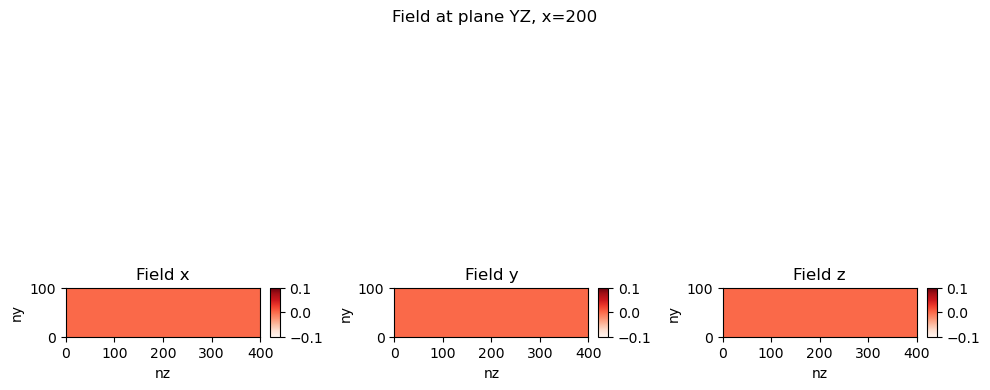

In [17]:
solver.sigma.inspect(
    plane="YZ",
)

In [18]:
pl = solver.inspect(
    wake=wake,
    opacity=1.0,
    add_silhouette=True,
    off_screen=False,
    specular=0.0,
    smooth_shading=False,
)

Widget(value='<iframe src="http://localhost:40467/index.html?ui=P_0x7f7abfc5e5d0_6&reconnect=auto" class="pyvi…

## Run Simulation

In [ ]:
solver.wakesolve(
    wakelength=wakelength,
    wake=wake,
    plot=False,
    plot_func=solver.plot2D,
    plot_every=100,
    plot_until=10000,
)

## Plot Results

In [ ]:
# Plot longitudinal wake potential and impedance
fig1, ax = plt.subplots(1,2, figsize=[12,4], dpi=150)
ax[0].plot(wake.s*1e2, wake.WP, c='tab:red', lw=1.5, label='Wakis')
ax[0].set_xlabel('s [cm]')
ax[0].set_ylabel('Longitudinal wake potential [V/pC]', color='tab:red')
ax[0].legend()
ax[0].set_xlim(xmax=wakelength*1e2)

ax[1].plot(wake.f*1e-9, np.abs(wake.Z), c='tab:blue', alpha=0.8, lw=2, label='Abs')
ax[1].plot(wake.f*1e-9, np.real(wake.Z), ls='--', c='tab:blue', lw=1.5, label='Real')
ax[1].plot(wake.f*1e-9, np.imag(wake.Z), ls=':', c='tab:blue', lw=1.5, label='Imag')
ax[1].set_xlabel('f [GHz]')
ax[1].set_ylabel('Longitudinal impedance [Abs][$\Omega$]', color='tab:blue')
ax[1].legend()

fig1.tight_layout()
fig1.savefig(results_folder+'longitudinal.png')
plt.show()

In [ ]:
# Plot transverse x wake potential and impedance
fig2, ax = plt.subplots(1,2, figsize=[12,4], dpi=150)
ax[0].plot(wake.s*1e2, wake.WPx, c='tab:orange', lw=1.5, label='Wakis')
ax[0].set_xlabel('s [cm]')
ax[0].set_ylabel('Transverse wake potential X [V/pC]', color='tab:orange')
ax[0].legend()
ax[0].set_xlim(xmax=wakelength*1e2)

ax[1].plot(wake.fx*1e-9, np.abs(wake.Zx), c='tab:green', lw=2, label='Abs')
ax[1].plot(wake.fx*1e-9, np.real(wake.Zx), c='tab:green', ls='--', lw=1.5, label='Real')
ax[1].plot(wake.fx*1e-9, np.imag(wake.Zx), c='tab:green', ls=':', lw=1.5, label='Imag')
ax[1].set_xlabel('f [GHz]')
ax[1].set_ylabel('Transverse impedance X [Abs][$\Omega$]', color='tab:green')
ax[1].legend()

fig2.tight_layout()
fig2.savefig(results_folder+'001_transverse_x.png')
plt.show()

In [ ]:
# Plot transverse y wake potential and impedance
fig3, ax = plt.subplots(1,2, figsize=[12,4], dpi=150)
ax[0].plot(wake.s*1e2, wake.WPy, c='tab:brown', lw=1.5, label='Wakis')
ax[0].set_xlabel('s [cm]')
ax[0].set_ylabel('Transverse wake potential Y [V/pC]', color='tab:brown')
ax[0].legend()
ax[0].set_xlim(xmax=wakelength*1e2)

ax[1].plot(wake.fy*1e-9, np.abs(wake.Zy), c='tab:pink', lw=2, label='Abs')
ax[1].plot(wake.fy*1e-9, np.real(wake.Zy), c='tab:pink', ls='--', lw=1.5, label='Real')
ax[1].plot(wake.fy*1e-9, np.imag(wake.Zy), c='tab:pink', ls=':', lw=1.5, label='Imag')
ax[1].set_xlabel('f [GHz]')
ax[1].set_ylabel('Transverse impedance Y [Abs][$\Omega$]', color='tab:pink')
ax[1].legend()

fig3.tight_layout()
fig3.savefig(results_folder+'transverse_y.png')
plt.show()